Setting up the Loan Dataset

In [25]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import plotly.express as px
import csv

In [2]:
df = pd.read_csv('C:\Projects\loan.csv')
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\razor\AppData\Local\Temp\ipykernel_15812\225397999.py:1: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv('C:\Projects\loan.csv')
C:\Users\razor\AppData\Local\Temp\ipykernel_15812\225397999.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\Projects\loan.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
columns_to_keep = ['loan_amnt', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'loan_status', 'purpose']
loan_df = df[columns_to_keep]

loan_df['loan_percent_income'] = loan_df['loan_amnt'] / loan_df['annual_inc']

loan_df.columns = ['loan_amnt', 'loan_int_rate', 'installment', 'loan_grade', 'person_emp_length', 'person_home_ownership', 'person_income', 'loan_status', 'loan_intent', 'loan_percent_income']

loan_df['person_age'] = np.random.randint(18, 110, loan_df.shape[0])
loan_df

C:\Users\razor\AppData\Local\Temp\ipykernel_15812\4255958765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df['loan_percent_income'] = loan_df['loan_amnt'] / loan_df['annual_inc']
C:\Users\razor\AppData\Local\Temp\ipykernel_15812\4255958765.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df['person_age'] = np.random.randint(18, 110, loan_df.shape[0])


,loan_amnt,loan_int_rate,installment,loan_grade,person_emp_length,person_home_ownership,person_income,loan_status,loan_intent,loan_percent_income,person_age
0,2500,13.56,84.92,C,10+ years,RENT,55000.0,Current,debt_consolidation,0.045455,59
1,30000,18.94,777.23,D,10+ years,MORTGAGE,90000.0,Current,debt_consolidation,0.333333,47
2,5000,17.97,180.69,D,6 years,MORTGAGE,59280.0,Current,debt_consolidation,0.084345,97
3,4000,18.94,146.51,D,10+ years,MORTGAGE,92000.0,Current,debt_consolidation,0.043478,18
4,30000,16.14,731.78,C,10+ years,MORTGAGE,57250.0,Current,debt_consolidation,0.524017,97
...,...,...,...,...,...,...,...,...,...,...,...
2260663,12000,14.08,279.72,C,10+ years,MORTGAGE,58000.0,Current,debt_consolidation,0.206897,44
2260664,12000,25.82,358.01,E,< 1 year,MORTGAGE,30000.0,Fully Paid,debt_consolidation,0.400000,87
2260665,10000,11.99,332.10,B,10+ years,OWN,64000.0,Current,debt_consolidation,0.156250,39
2260666,12000,21.45,327.69,D,NaN,RENT,60000.0,Current,debt_consolidation,0.200000,92


Exploring Credit Data

In [4]:
# Check the structure of the data
print(loan_df.dtypes)

# Check the first five rows of the data
print(loan_df.head(5))

loan_amnt                  int64
loan_int_rate            float64
installment              float64
loan_grade                object
person_emp_length         object
person_home_ownership     object
person_income            float64
loan_status               object
loan_intent               object
loan_percent_income      float64
person_age                 int32
dtype: object
   loan_amnt  loan_int_rate  installment loan_grade person_emp_length  \
0       2500          13.56        84.92          C         10+ years   
1      30000          18.94       777.23          D         10+ years   
2       5000          17.97       180.69          D           6 years   
3       4000          18.94       146.51          D         10+ years   
4      30000          16.14       731.78          C         10+ years   

  person_home_ownership  person_income loan_status         loan_intent  \
0                  RENT        55000.0     Current  debt_consolidation   
1              MORTGAGE        90000

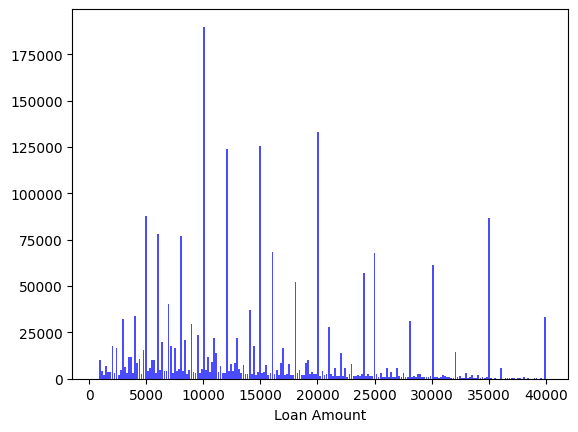

In [5]:
# Look at the distribution of loan amounts with a histogram
n, bins, patches = plt.hist(x=loan_df['loan_amnt'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("Loan Amount")
plt.show()

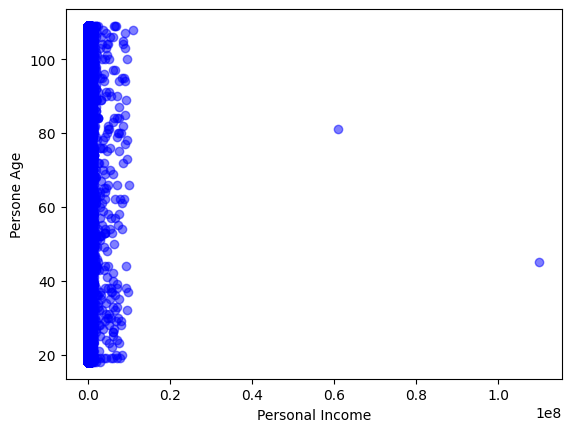

In [6]:
# Plot a scatter plot of income against age
plt.scatter(loan_df['person_income'], loan_df['person_age'],c='blue', alpha=0.5)
plt.xlabel('Personal Income')
plt.ylabel('Persone Age')
plt.show()

In [7]:
# Create a cross table of the loan intent and loan status
print(pd.crosstab(loan_df['loan_intent'], loan_df['loan_status'], margins = True))

loan_status         Charged Off  Current  Default  \
loan_intent                                         
car                        2067     9502        1   
credit_card               48646   224406        4   
debt_consolidation       161039   499009       19   
educational                  56        1        0   
home_improvement          15085    63435        2   
house                      1513     6820        0   
major_purchase             5304    21130        0   
medical                    3291    11913        1   
moving                     2150     5899        1   
other                     15864    61546        3   
renewable_energy            216      511        0   
small_business             4465     8989        0   
vacation                   1680     6529        0   
wedding                     279        5        0   
All                      261655   919695       31   

loan_status         Does not meet the credit policy. Status:Charged Off  \
loan_intent            

In [8]:
# Example of using pd.crosstab to create a cross table
print(pd.crosstab(loan_df['person_home_ownership'], [loan_df['loan_status'], loan_df['loan_grade']]))

loan_status           Charged Off                                          \
loan_grade                      A      B      C      D      E     F     G   
person_home_ownership                                                       
ANY                             2     12     14     11      8     3     2   
MORTGAGE                     6808  22399  35093  24568  14947  5997  1850   
NONE                            0      4      1      2      0     0     0   
OTHER                           2     10      4      6      3     2     0   
OWN                          1661   5794   9205   6439   3823  1555   534   
RENT                         5293  22858  38945  28415  16583  6706  2096   

loan_status           Current                  ... Late (16-30 days)          \
loan_grade                  A       B       C  ...                 E   F   G   
person_home_ownership                          ...                             
ANY                       185     235     174  ...                

In [9]:
# Create a cross table of home ownership, loan status, and average percent income
print(pd.crosstab(loan_df['person_home_ownership'], loan_df['loan_status'],
              values=loan_df['loan_percent_income'], aggfunc='mean'))

loan_status            Charged Off   Current   Default  \
person_home_ownership                                    
ANY                       0.193684  0.234007       NaN   
MORTGAGE                       inf       inf  0.230306   
NONE                      0.261008  1.346154       NaN   
OTHER                     0.255231       NaN       NaN   
OWN                            inf       inf  0.399952   
RENT                           inf       inf  0.227839   

loan_status            Does not meet the credit policy. Status:Charged Off  \
person_home_ownership                                                        
ANY                                                                  NaN     
MORTGAGE                                                        0.156351     
NONE                                                            0.208333     
OTHER                                                           0.179659     
OWN                                                             0.1

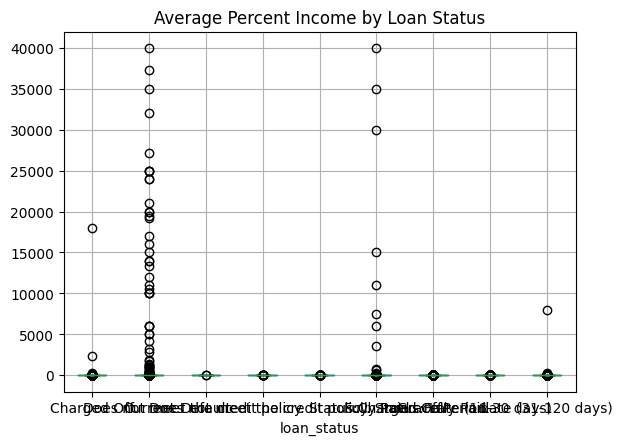

In [10]:
# Create a box plot of percentage income by loan status
loan_df.boxplot(column = ['loan_percent_income'], by = 'loan_status')
plt.title('Average Percent Income by Loan Status')
plt.suptitle('')
plt.show()

Dealing with Outliers

In [13]:
loan_df['person_emp_length'] = loan_df['person_emp_length'].str.extract(r'(\d+)')
loan_df.dropna(subset=['person_emp_length'], inplace=True)
loan_df['person_emp_length'] = loan_df['person_emp_length'].astype(int)

loan_df

C:\Users\razor\AppData\Local\Temp\ipykernel_15812\3643742495.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df['person_emp_length'] = loan_df['person_emp_length'].str.extract(r'(\d+)')
C:\Users\razor\AppData\Local\Temp\ipykernel_15812\3643742495.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df.dropna(subset=['person_emp_length'], inplace=True)
C:\Users\razor\AppData\Local\Temp\ipykernel_15812\3643742495.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

,loan_amnt,loan_int_rate,installment,loan_grade,person_emp_length,person_home_ownership,person_income,loan_status,loan_intent,loan_percent_income,person_age
0,2500,13.56,84.92,C,10,RENT,55000.0,Current,debt_consolidation,0.045455,59
1,30000,18.94,777.23,D,10,MORTGAGE,90000.0,Current,debt_consolidation,0.333333,47
2,5000,17.97,180.69,D,6,MORTGAGE,59280.0,Current,debt_consolidation,0.084345,97
3,4000,18.94,146.51,D,10,MORTGAGE,92000.0,Current,debt_consolidation,0.043478,18
4,30000,16.14,731.78,C,10,MORTGAGE,57250.0,Current,debt_consolidation,0.524017,97
...,...,...,...,...,...,...,...,...,...,...,...
2260662,30000,30.75,984.47,F,6,MORTGAGE,100000.0,Current,debt_consolidation,0.300000,84
2260663,12000,14.08,279.72,C,10,MORTGAGE,58000.0,Current,debt_consolidation,0.206897,44
2260664,12000,25.82,358.01,E,1,MORTGAGE,30000.0,Fully Paid,debt_consolidation,0.400000,87
2260665,10000,11.99,332.10,B,10,OWN,64000.0,Current,debt_consolidation,0.156250,39


In [16]:

# Example of using aggfunc with both min and max
print(pd.crosstab(loan_df['loan_status'], loan_df['person_home_ownership'],
                  values=loan_df['person_emp_length'], aggfunc=['min', 'max']))

                                                    min                      \
person_home_ownership                               ANY MORTGAGE NONE OTHER   
loan_status                                                                   
Charged Off                                         1.0      1.0  1.0   1.0   
Current                                             1.0      1.0  NaN   NaN   
Default                                             NaN      2.0  NaN   NaN   
Does not meet the credit policy. Status:Charged...  NaN      1.0  6.0   1.0   
Does not meet the credit policy. Status:Fully Paid  NaN      1.0  1.0   1.0   
Fully Paid                                          1.0      1.0  1.0   1.0   
In Grace Period                                     1.0      1.0  NaN   NaN   
Late (16-30 days)                                   2.0      1.0  NaN   NaN   
Late (31-120 days)                                  1.0      1.0  NaN   NaN   

                                                   

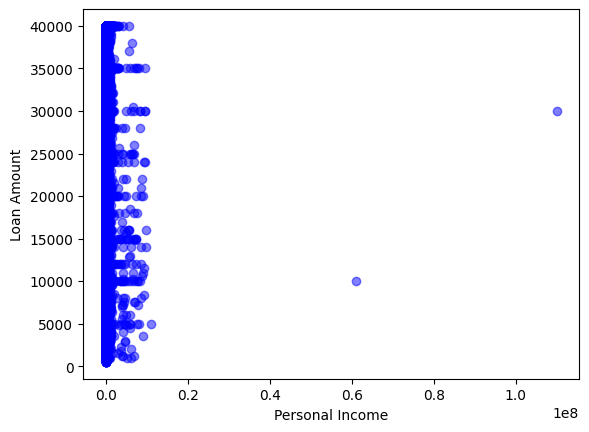

In [ ]:
# Create the scatter plot for income and amount
plt.scatter(loan_df['person_income'], loan_df['loan_amnt'], c='blue', alpha=0.5)
plt.xlabel("Personal Income")
plt.ylabel("Loan Amount")
plt.show()

In [27]:
# Use Pandas to drop the record from the data frame and create a new one
loan_df_new = loan_df.drop(loan_df[loan_df['person_income'] > 6*10**8].index)